In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

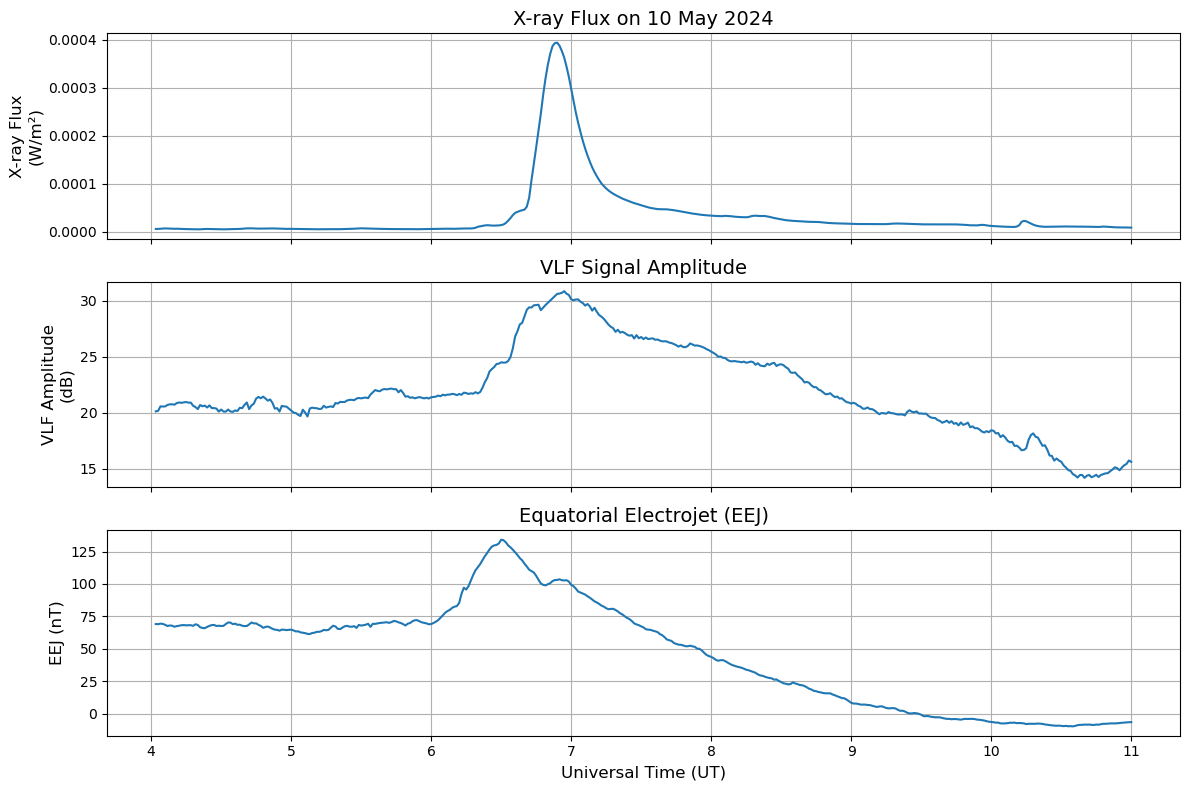

In [13]:
# Recreation of UT on 10 May 2024

# Load file
vlf10_df = pd.read_csv('../data/magnetometer_data/VLF_XrayFlux/Figure_X_10May2024.csv')

# Drop rows with missing values in any relevant columns
plot_vlf10_df = vlf10_df.dropna(subset=['Xray Flux', 'VLF amp', 'EEJ'])

# Set up a multi-panel plot
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# X-ray Flux
axs[0].plot(plot_vlf10_df['UT'], plot_vlf10_df['Xray Flux'], linewidth=1.5)
axs[0].set_ylabel('X-ray Flux\n(W/m²)', fontsize=12)
axs[0].set_title('X-ray Flux on 10 May 2024', fontsize=14)
axs[0].grid(True)

# VLF Amplitude
axs[1].plot(plot_vlf10_df['UT'], plot_vlf10_df['VLF amp'], linewidth=1.5)
axs[1].set_ylabel('VLF Amplitude\n(dB)', fontsize=12)
axs[1].set_title('VLF Signal Amplitude', fontsize=14)
axs[1].grid(True)

# EEJ
axs[2].plot(plot_vlf10_df['UT'], plot_vlf10_df['EEJ'], linewidth=1.5)
axs[2].set_ylabel('EEJ (nT)', fontsize=12)
axs[2].set_xlabel('Universal Time (UT)', fontsize=12)
axs[2].set_title('Equatorial Electrojet (EEJ)', fontsize=14)
axs[2].grid(True)

plt.tight_layout()
plt.savefig('GOES_SOLAR_10_2024.png')
plt.show()


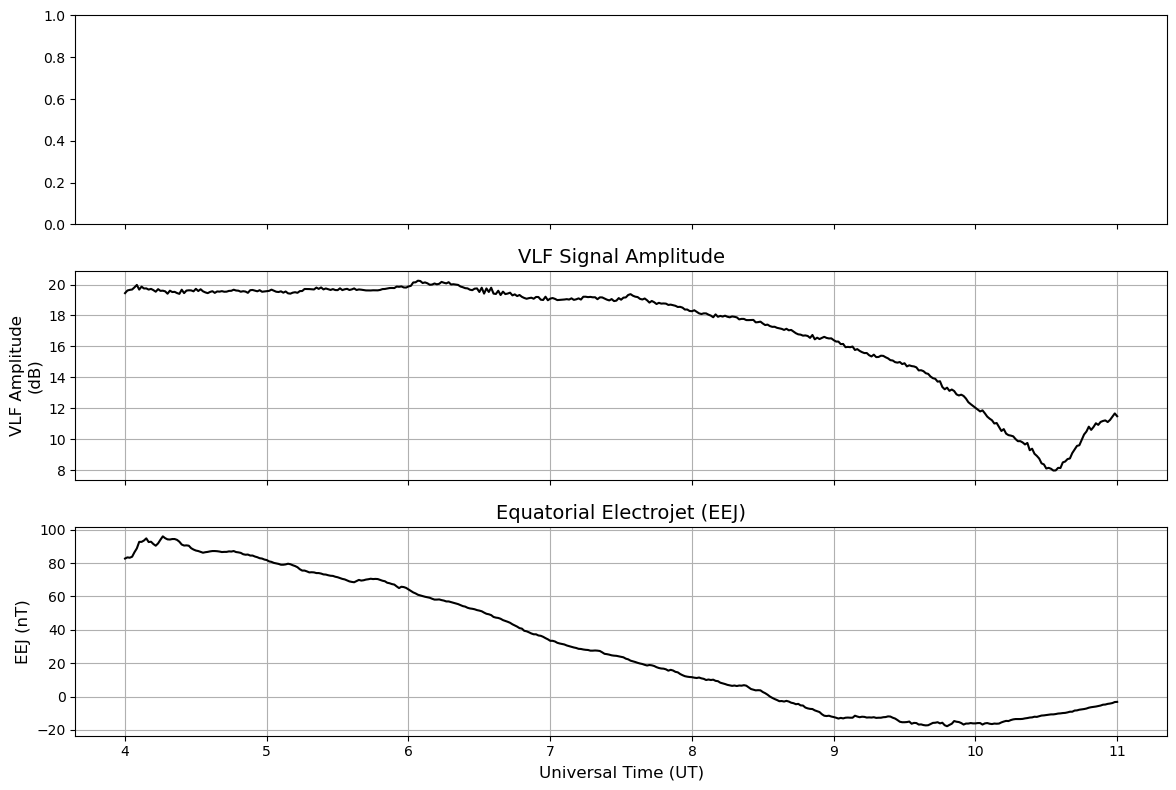

In [12]:
# Make same graph but of 9 May 2024

# Load file
vlf09_df = pd.read_csv('../data/magnetometer_data/VLF_XrayFlux/Figure_X_09May2024.csv')
vlf09_df
# Drop rows with missing values in any relevant columns
plot_vlf09_df = vlf09_df.dropna(subset=['VLF','EEJ'])

# Set up a multi-panel plot
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# VLF Amplitude
axs[1].plot(plot_vlf09_df['UT'], plot_vlf09_df['VLF'], color='black', linewidth=1.5)
axs[1].set_ylabel('VLF Amplitude\n(dB)', fontsize=12)
axs[1].set_title('VLF Signal Amplitude', fontsize=14)
axs[1].grid(True)

# EEJ
axs[2].plot(plot_vlf09_df['UT'], plot_vlf09_df['EEJ'], color='black', linewidth=1.5)
axs[2].set_ylabel('EEJ (nT)', fontsize=12)
axs[2].set_xlabel('Universal Time (UT)', fontsize=12)
axs[2].set_title('Equatorial Electrojet (EEJ)', fontsize=14)
axs[2].grid(True)

plt.tight_layout()
plt.savefig('GOES_SOLAR_9_2024.png')
plt.show()

In [5]:
# Choose a specific ionogram file to test
file_path = '../data/magnetometer_data/Ionograms/202405100630.txt'  # change this if needed

# Load with flexible parsing (skip bad lines)
df = pd.read_csv(file_path, sep=r'\s+', header=None, engine='python', on_bad_lines='skip')

# Show first 10 rows
print(df.head(10))
print(f"\nShape: {df.shape}")

       0      1     2   3    4     5   6    7   8   9
0  %year  month  date  hr  min  Freq  Ht  Amp  xx  xx

Shape: (1, 10)


In [6]:
ionogram_files = sorted(glob.glob('../data/magnetometer_data/Ionograms/*.txt'))  # adjust path if needed

# Check which files have data
for f in ionogram_files:
    try:
        df = pd.read_csv(f, sep=r'\s+', header=0, engine='python', on_bad_lines='skip')
        if df.shape[0] > 1:
            print(f"{f} --> {df.shape[0]} rows")
    except Exception as e:
        print(f"{f} --> ERROR: {e}")


../data/magnetometer_data/Ionograms\202405100630.txt --> 218 rows
../data/magnetometer_data/Ionograms\202405100640.txt --> 36 rows
../data/magnetometer_data/Ionograms\202405100650.txt --> 67 rows
../data/magnetometer_data/Ionograms\202405100700.txt --> 49 rows
../data/magnetometer_data/Ionograms\202405100710.txt --> 71 rows
../data/magnetometer_data/Ionograms\202405100720.txt --> 256 rows


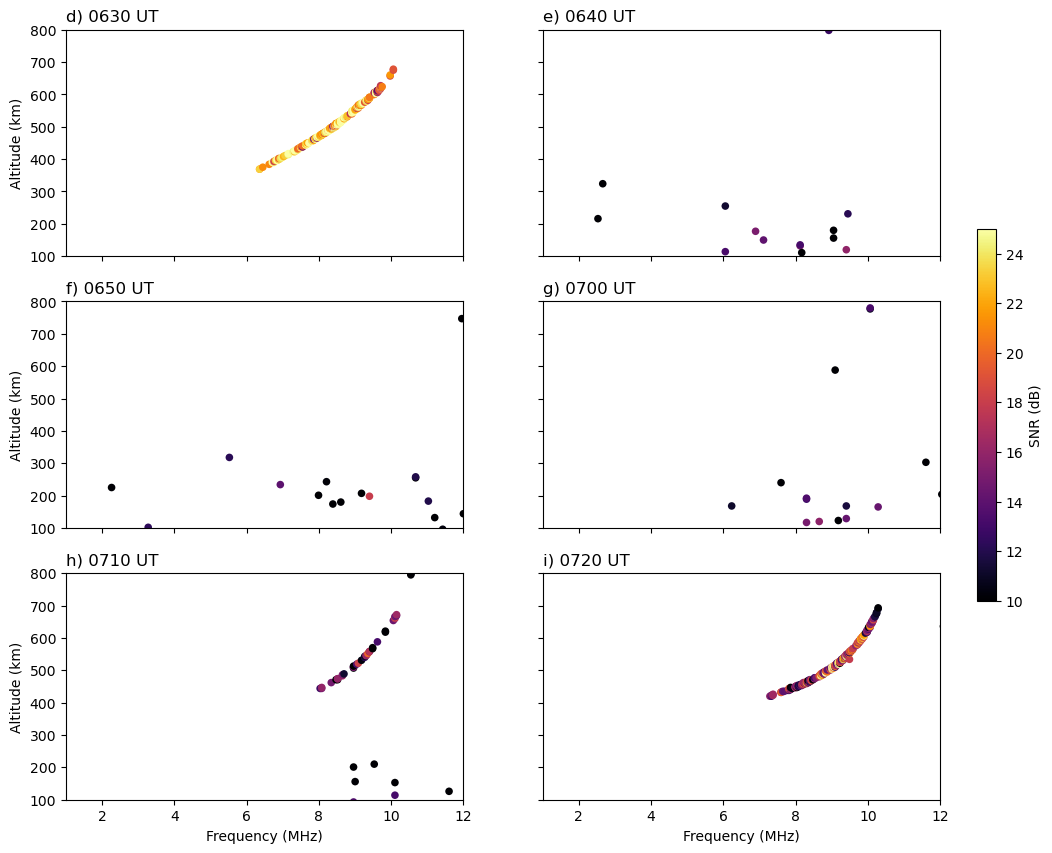

In [11]:
# File paths
file_paths = [
    "../data/magnetometer_data/Ionograms/202405100630.txt",
    "../data/magnetometer_data/Ionograms/202405100640.txt",
    "../data/magnetometer_data/Ionograms/202405100650.txt",
    "../data/magnetometer_data/Ionograms/202405100700.txt",
    "../data/magnetometer_data/Ionograms/202405100710.txt",
    "../data/magnetometer_data/Ionograms/202405100720.txt"
]
time_labels = ['0630 UT', '0640 UT', '0650 UT', '0700 UT', '0710 UT', '0720 UT']

# Plot setup
fig, axs = plt.subplots(3, 2, figsize=(12, 10), sharex=True, sharey=True)
axs = axs.ravel()
scatter_for_colorbar = None

for i, path in enumerate(file_paths):
    df = pd.read_csv(path, sep=r'\s+', engine='python', skiprows=1, header=None)
    
    # Extract only Freq, Ht, Amp (columns 5, 6, 7)
    df = df.iloc[:, [5, 6, 7]]
    df.columns = ['Freq', 'Ht', 'Amp']
    
    # Convert to numeric, drop rows with invalid values
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    df = df[(df['Ht'] > 0) & (df['Amp'] > 0)]

    if not df.empty:
        sc = axs[i].scatter(df['Freq'], df['Ht'], c=df['Amp'], cmap='inferno', vmin=10, vmax=25, s=30, edgecolors='none')
        scatter_for_colorbar = sc

    axs[i].set_title(f"{chr(100 + i)}) {time_labels[i]}", loc='left')
    axs[i].set_xlim(1, 12)
    axs[i].set_ylim(100, 800)

# Labeling
for ax in axs[4:]:
    ax.set_xlabel("Frequency (MHz)")
for i in [0, 2, 4]:
    axs[i].set_ylabel("Altitude (km)")

# Shared colorbar
if scatter_for_colorbar:
    cbar = fig.colorbar(scatter_for_colorbar, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label("SNR (dB)")

plt.savefig('GOES_IONOGRAM_10_2024.png')
plt.show()

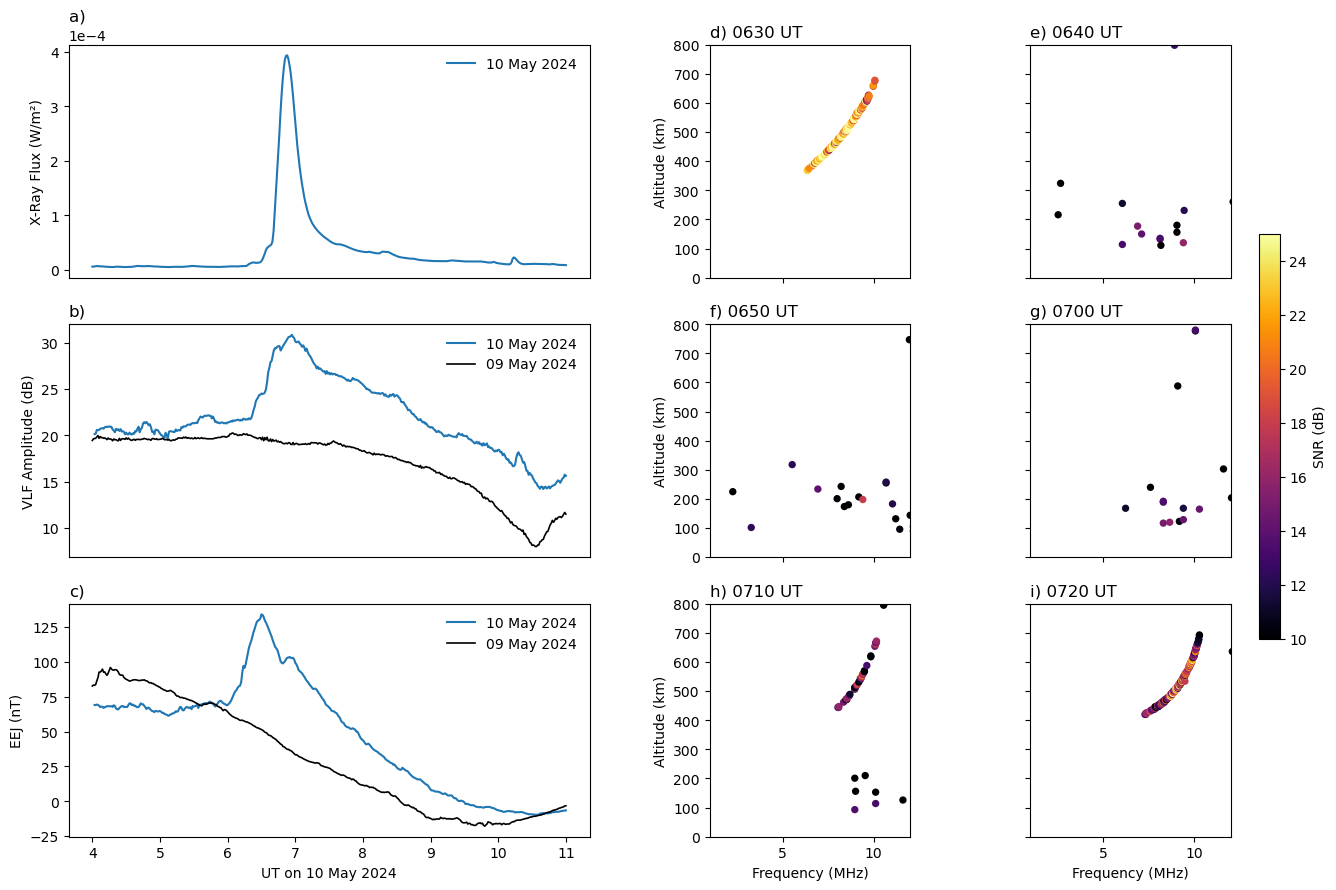

In [10]:
# Load both May 10 and May 9 data
may10 = pd.read_csv("../data/magnetometer_data/VLF_XrayFlux/Figure_X_10May2024.csv").dropna(subset=['Xray Flux', 'VLF amp', 'EEJ'])
may9 = pd.read_csv("../data/magnetometer_data/VLF_XrayFlux/Figure_X_09May2024.csv").dropna(subset=['VLF','EEJ'])

# Ionogram setup (same as before)
ionogram_paths = [
    "../data/magnetometer_data/Ionograms/202405100630.txt",
    "../data/magnetometer_data/Ionograms/202405100640.txt",
    "../data/magnetometer_data/Ionograms/202405100650.txt",
    "../data/magnetometer_data/Ionograms/202405100700.txt",
    "../data/magnetometer_data/Ionograms/202405100710.txt",
    "../data/magnetometer_data/Ionograms/202405100720.txt"
]
ionogram_labels = ['d) 0630 UT', 'e) 0640 UT', 'f) 0650 UT', 'g) 0700 UT', 'h) 0710 UT', 'i) 0720 UT']

# Master figure
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(3, 4, wspace=0.6)

# a) X-ray flux
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.plot(may10['UT'], may10['Xray Flux'], color='tab:blue', linewidth=1.5, label='10 May 2024')
ax1.set_ylabel("X-Ray Flux (W/m²)")
ax1.set_title("a)", loc='left')
ax1.set_xticks([])
ax1.legend(frameon=False)
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# b) VLF
ax2 = fig.add_subplot(gs[1, 0:2])
ax2.plot(may10['UT'], may10['VLF amp'], label='10 May 2024', color='tab:blue', linewidth=1.5)
ax2.plot(may9['UT'], may9['VLF'], label='09 May 2024', color='black', linewidth=1.2)
ax2.set_ylabel("VLF Amplitude (dB)")
ax2.set_title("b)", loc='left')
ax2.legend(frameon=False)
ax2.set_xticks([])

# c) EEJ
ax3 = fig.add_subplot(gs[2, 0:2])
ax3.plot(may10['UT'], may10['EEJ'], label='10 May 2024', color='tab:blue', linewidth=1.5)
ax3.plot(may9['UT'], may9['EEJ'], label='09 May 2024', color='black', linewidth=1.2)
ax3.set_ylabel("EEJ (nT)")
ax3.set_xlabel("UT on 10 May 2024")
ax3.set_title("c)", loc='left')
ax3.legend(frameon=False)

# Ionogram scatter plots
scatter_for_colorbar = None
for i, path in enumerate(ionogram_paths):
    row = i // 2
    col = 2 + (i % 2)
    ax = fig.add_subplot(gs[row, col])
    
    df = pd.read_csv(path, sep=r'\s+', skiprows=1, header=None, engine='python')
    df = df.iloc[:, [5, 6, 7]]
    df.columns = ['Freq', 'Ht', 'Amp']
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    df = df[(df['Freq'] > 0) & (df['Ht'] > 0) & (df['Amp'] > 0)]
    
    if not df.empty:
        sc = ax.scatter(df['Freq'], df['Ht'], c=df['Amp'], cmap='inferno', vmin=10, vmax=25, s=28, edgecolors='none')
        scatter_for_colorbar = sc

    ax.set_xlim(1, 12)
    ax.set_ylim(0, 800)
    ax.set_title(ionogram_labels[i], loc='left')
    if row == 2:
        ax.set_xlabel("Frequency (MHz)")
    if col == 2:
        ax.set_ylabel("Altitude (km)")

    if row != 2:
        ax.set_xticklabels([])
    if col != 2:
        ax.set_yticklabels([])

# Colorbar
if scatter_for_colorbar:
    cbar_ax = fig.add_axes([0.92, 0.29, 0.015, 0.45])
    cbar = fig.colorbar(scatter_for_colorbar, cax=cbar_ax)
    cbar.set_label("SNR (dB)")

plt.subplots_adjust(
    left=0.07,   # space on left side of figure
    right=0.90,  # leave room for the colorbar
    bottom=0.07,
    top=0.95,
    wspace=0.3,  # more space between columns
    hspace=0.2   # more space between rows
)
plt.show()